# Stock Price Prediction: Short-Term Forecasting

In [1]:
# Install yfinance if not already available (needed on Kaggle)
!pip install yfinance 

In [2]:
# Install & Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Fetches historical stock data from Yahoo Finance
import yfinance as yf              


In [3]:
# Configurating stock symbol: AAPL=Apple
TICKER   = "AAPL"     
# Start date for historical data
START    = "2020-01-01"  
# End date for historical data
END      = "2024-12-31"

# Download Data, by fetching Historical Stock Data via yfinance
df = yf.download(TICKER, start=START, end=END)

# Flatten multi-level column index (yfinance v0.2+ returns MultiIndex)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

print(f"\n Downloaded {len(df)} trading days of data for {TICKER}")
print(f"   Date range: {df.index[0].date()}  →  {df.index[-1].date()}")
df.head()

[*********************100%***********************]  1 of 1 completed


 Downloaded 1257 trading days of data for AAPL
   Date range: 2020-01-02  →  2024-12-30


Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.333862,72.394070,71.091169,71.344039,135480400
2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800
2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200
2020-01-07,71.861839,72.466322,71.642681,72.211041,108872000
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200


In [4]:
# displaying data
print("📋 Dataset shape:", df.shape)
print("\n📋 Data types:")
print(df.dtypes)
print("\n📋 Missing values per column:")
print(df.isnull().sum())
print("\n📋 Summary statistics:")
df.describe().round(2)

📋 Dataset shape: (1257, 5)

📋 Data types:
Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

📋 Missing values per column:
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

📋 Summary statistics:


Price,Close,High,Low,Open,Volume
count,1257.00,1257.00,1257.00,1257.00,1.257000e+03
mean,151.30,152.82,149.60,151.14,9.061168e+07
std,41.78,41.92,41.55,41.72,5.324605e+07
min,54.16,55.16,51.32,55.06,2.323470e+07
25%,126.25,127.33,124.23,125.72,5.546960e+07
50%,149.94,151.69,147.95,149.77,7.629970e+07
75%,175.75,177.45,174.32,175.59,1.077601e+08
max,257.38,258.45,255.99,256.55,4.265100e+08


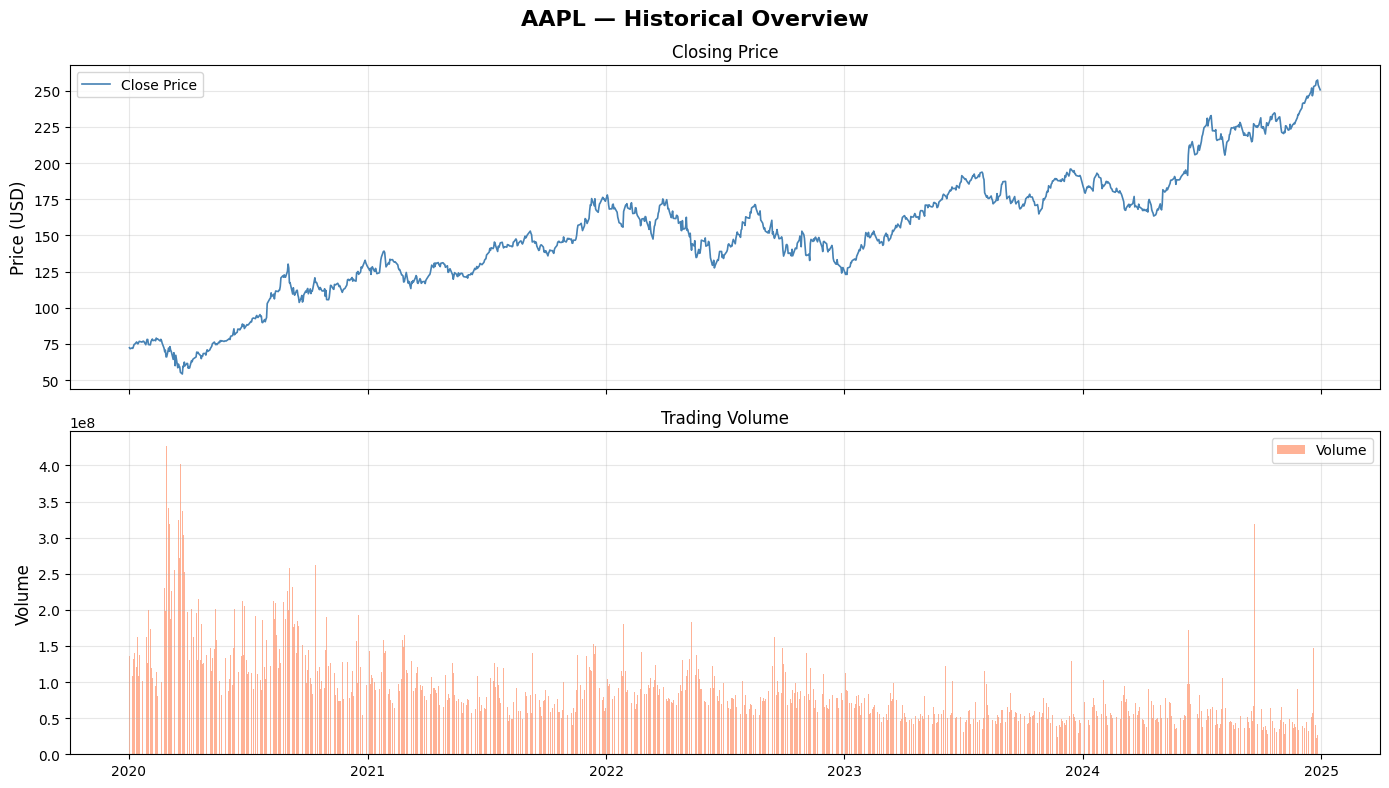

In [5]:
# Visualise Raw Closing Price
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle(f"{TICKER} — Historical Overview", fontsize=16, fontweight='bold')

# Top panel: Closing price
axes[0].plot(df.index, df['Close'], color='steelblue', linewidth=1.2, label='Close Price')
axes[0].set_ylabel('Price (USD)', fontsize=12)
axes[0].set_title('Closing Price')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Bottom panel: Trading volume
axes[1].bar(df.index, df['Volume'], color='coral', alpha=0.6, label='Volume')
axes[1].set_ylabel('Volume', fontsize=12)
axes[1].set_title('Trading Volume')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

In [6]:
# Copy the original download, Features (X): Today's Open, High, Low, Volume
data = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

# Technical Indicator Features, these rolling statistics give the model historical context:

# Price range within the day (volatility proxy)
data['Daily_Range']   = data['High'] - data['Low']

# Difference between today's close and open (momentum proxy)
data['Close_Open_Diff'] = data['Close'] - data['Open']

# 5-day and 10-day simple moving averages of Close price
data['MA_5']  = data['Close'].rolling(window=5).mean()
data['MA_10'] = data['Close'].rolling(window=10).mean()

# 5-day rolling standard deviation (recent volatility)
data['Volatility_5'] = data['Close'].rolling(window=5).std()

# Previous day's close (lag feature — very predictive for next-day price)
data['Prev_Close'] = data['Close'].shift(1)

# Target Variable (y): Tomorrow's Close price ← shifted by 1 day using .shift(-1)
# shift(-1) moves next row's Close into the current row -> "tomorrow's close"
data['Target'] = data['Close'].shift(-1)

# Drop rows with NaN (from rolling windows and the last row with no target) 
data.dropna(inplace=True)

print(f" Feature engineering complete. Dataset shape: {data.shape}")
print("\n📋 Features created:")
print(data.columns.tolist())
data.head(3)

 Feature engineering complete. Dataset shape: (1247, 12)

📋 Features created:
['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Range', 'Close_Open_Diff', 'MA_5', 'MA_10', 'Volatility_5', 'Prev_Close', 'Target']


Price,Open,High,Low,Close,Volume,Daily_Range,Close_Open_Diff,MA_5,MA_10,Volatility_5,Prev_Close,Target
Date,,,,,,,,,,,,
2020-01-15,75.103425,75.982460,74.549507,74.980598,121923600,1.432953,-0.122827,75.184837,73.696979,0.699329,75.303329,75.919861
2020-01-16,75.522490,76.030649,75.161242,75.919861,108829200,0.869407,0.397371,75.455048,74.055579,0.661805,74.980598,76.760345
2020-01-17,76.167894,76.762749,75.862040,76.760345,137816400,0.900709,0.592452,75.859644,74.568549,0.728387,75.919861,76.240181


In [7]:
# Define Feature Columns & Target
FEATURE_COLS = [
    'Open', 'High', 'Low', 'Volume',
    'Daily_Range', 'Close_Open_Diff',
    'MA_5', 'MA_10', 'Volatility_5', 'Prev_Close'
]
# Next day's closing price
TARGET_COL = 'Target' 

# Feature matrix  (n_samples × n_features)
X = data[FEATURE_COLS].values   
# Target vector   (n_samples,)
y = data[TARGET_COL].values    
# Keep dates for plotting later
dates = data.index              

# Chronological 80/20 Split, 
# shuffle=False preserves time order (critical for time series!) i.e. train on the past, test on the future.
X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(
    X, y, dates, test_size=0.20, shuffle=False
)

print(f" Training samples : {len(X_train):,}  ({dates_train[0].date()} → {dates_train[-1].date()})")
print(f" Test samples     : {len(X_test):,}  ({dates_test[0].date()} → {dates_test[-1].date()})")


# Feature Scaling using StandardScaler: zero mean, unit variance this helps Linear Regression converge
# Fit only on training data to prevent data leakage into the test set
scaler = StandardScaler()
#  fit + transform on train
X_train_scaled = scaler.fit_transform(X_train) 
# only transform on test
X_test_scaled  = scaler.transform(X_test)       

print("\n Train/test split and scaling complete.")

 Training samples : 997  (2020-01-15 → 2023-12-29)
 Test samples     : 250  (2024-01-02 → 2024-12-27)

 Train/test split and scaling complete.


In [8]:
# Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)   # Learn coefficients from training data
lr_preds = lr_model.predict(X_test_scaled)  # Predict on unseen test data

print(" Linear Regression trained.")

# Model 2: Random Forest Regressor 
rf_model = RandomForestRegressor(
    # n_estimators=200 -> 200 decision trees (averaged for prediction)
    n_estimators=200,
    # max_depth=10     -> limits tree depth to reduce overfitting
    max_depth=10,
    # Minimum samples required to split a node
    min_samples_split=5, 
    # random_state=42  -> ensures reproducibility
    random_state=42,
    # Use all CPU cores for speed
    n_jobs=-1             
)
rf_model.fit(X_train_scaled, y_train)   # Note: RF doesn't strictly need scaling
rf_preds = rf_model.predict(X_test_scaled)

print(" Random Forest trained.")

 Linear Regression trained.
 Random Forest trained.


In [9]:
# Evaluate Model Performance
def evaluate_model(name, y_true, y_pred):
    """
    Print a summary of regression metrics for a given model.
    
    Metrics explained:
    - MAE  (Mean Absolute Error)      : Average |actual - predicted| in USD
    - RMSE (Root Mean Squared Error)  : Like MAE but penalises large errors more
    - R²   (Coefficient of Determination) : 1.0 = perfect fit, 0 = baseline mean
    - MAPE (Mean Absolute % Error)    : Percentage error relative to actual price
    """
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"\n{'─'*40}")
    print(f"  {name}")
    print(f"{'─'*40}")
    print(f"  MAE  : ${mae:.4f}")
    print(f"  RMSE : ${rmse:.4f}")
    print(f"  R²   : {r2:.4f}")
    print(f"  MAPE : {mape:.2f}%")
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

lr_metrics = evaluate_model("Linear Regression", y_test, lr_preds)
rf_metrics = evaluate_model("Random Forest",     y_test, rf_preds)


────────────────────────────────────────
  Linear Regression
────────────────────────────────────────
  MAE  : $2.1761
  RMSE : $2.9174
  R²   : 0.9868
  MAPE : 1.06%

────────────────────────────────────────
  Random Forest
────────────────────────────────────────
  MAE  : $18.9764
  RMSE : $25.6704
  R²   : -0.0200
  MAPE : 8.38%


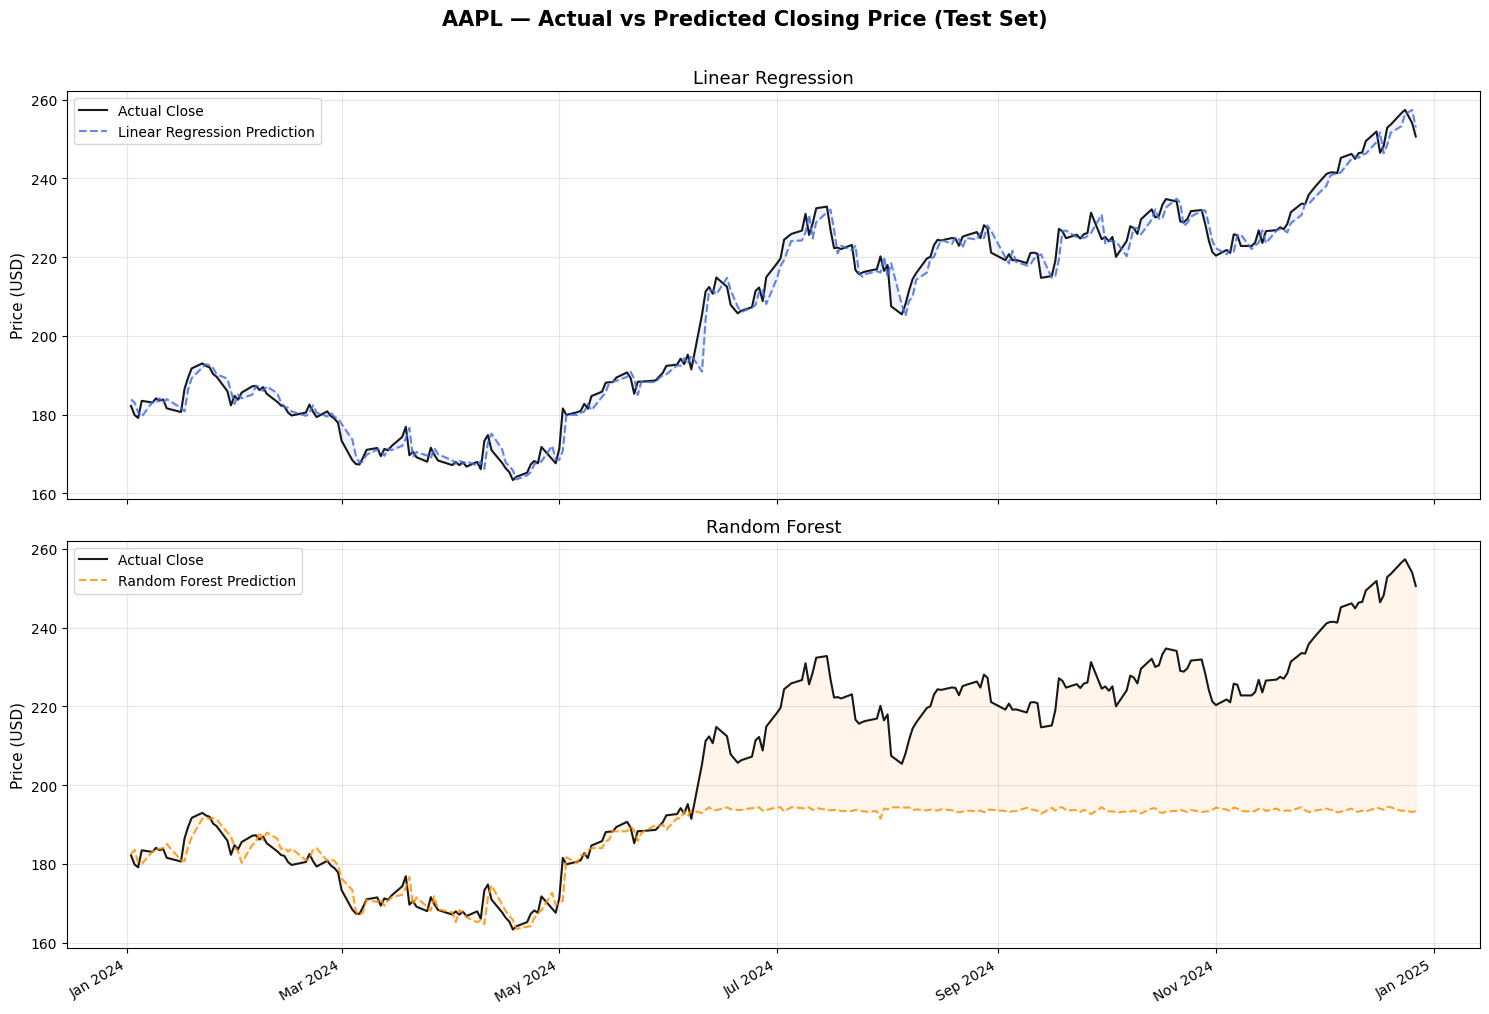

📁 Plot saved as 'actual_vs_predicted.png'


In [10]:
# Main Comparison Plot 
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
fig.suptitle(f"{TICKER} — Actual vs Predicted Closing Price (Test Set)",
             fontsize=15, fontweight='bold', y=1.01)

for ax, preds, title, color in zip(
    axes,
    [lr_preds, rf_preds],
    ["Linear Regression", "Random Forest"],
    ["royalblue", "darkorange"]
):
    # Plot Actual vs Predicted Prices
    ax.plot(dates_test, y_test,  color='black',  linewidth=1.5,
            label='Actual Close',  alpha=0.9)
    ax.plot(dates_test, preds, color=color, linewidth=1.5,
            label=f'{title} Prediction', alpha=0.8, linestyle='--')

    # Shade the error region between actual and predicted
    ax.fill_between(dates_test, y_test, preds, alpha=0.08, color=color)

    ax.set_title(title, fontsize=13)
    ax.set_ylabel("Price (USD)", fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("📁 Plot saved as 'actual_vs_predicted.png'")

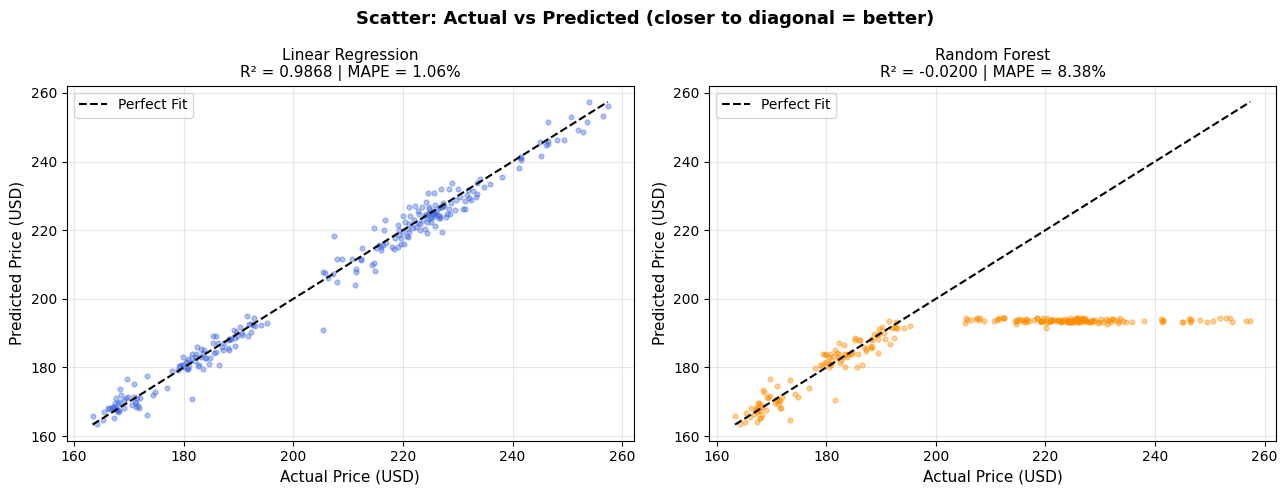

In [11]:
# Scatter Plot: Actual vs Predicted ( A perfect model would have all points on the diagonal y=x line)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Scatter: Actual vs Predicted (closer to diagonal = better)",
             fontsize=13, fontweight='bold')

for ax, preds, title, color, metrics in zip(
    axes,
    [lr_preds, rf_preds],
    ["Linear Regression", "Random Forest"],
    ["royalblue", "darkorange"],
    [lr_metrics, rf_metrics]
):
    ax.scatter(y_test, preds, alpha=0.4, s=12, color=color)

    # Perfect prediction line
    mn, mx = min(y_test.min(), preds.min()), max(y_test.max(), preds.max())
    ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1.5, label='Perfect Fit')

    ax.set_xlabel("Actual Price (USD)", fontsize=11)
    ax.set_ylabel("Predicted Price (USD)", fontsize=11)
    ax.set_title(f"{title}\nR² = {metrics['R2']:.4f} | MAPE = {metrics['MAPE']:.2f}%",
                 fontsize=11)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

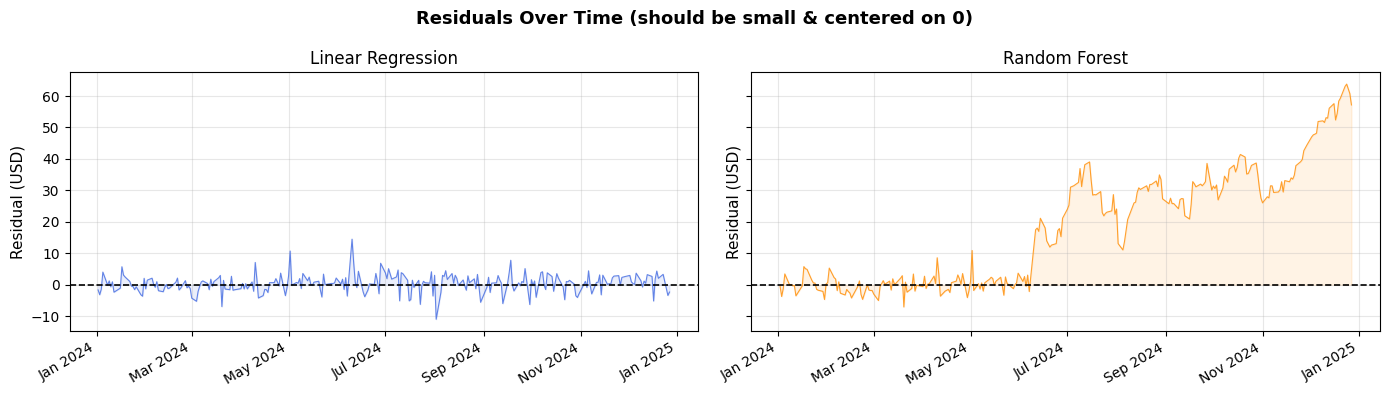

In [12]:
# Residual Plot: Prediction Errors Over Time, Residual = Actual − Predicted  (Ideally residuals should be small and randomly distributed around 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
fig.suptitle("Residuals Over Time (should be small & centered on 0)",
             fontsize=13, fontweight='bold')

for ax, preds, title, color in zip(
    axes,
    [lr_preds, rf_preds],
    ["Linear Regression", "Random Forest"],
    ["royalblue", "darkorange"]
):
    residuals = y_test - preds
    ax.plot(dates_test, residuals, color=color, linewidth=0.8, alpha=0.8)
    ax.axhline(0, color='black', linewidth=1.2, linestyle='--')  # zero line
    ax.fill_between(dates_test, residuals, 0, alpha=0.1, color=color)

    ax.set_title(title, fontsize=12)
    ax.set_ylabel("Residual (USD)", fontsize=11)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

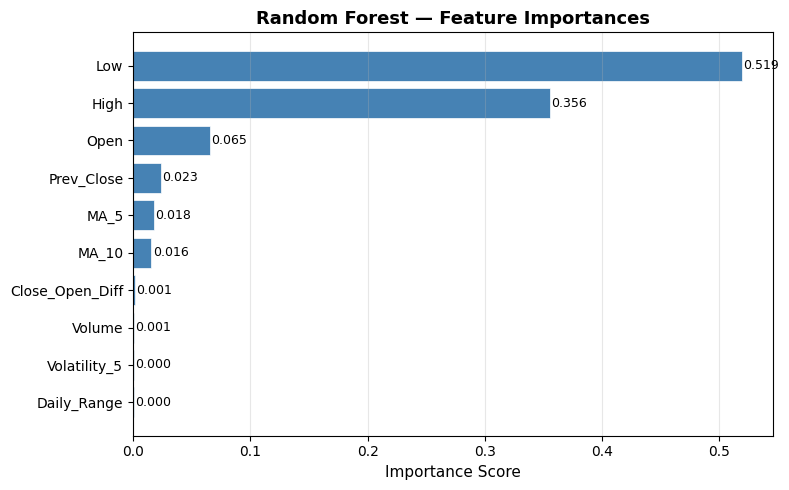


 Insight: Features with higher importance contributed more to predictions.
   'Prev_Close' and moving averages typically dominate for price prediction.


In [13]:
# Feature Importance: Random Forest can tell us which features contributed most to predictions
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': importances})
feat_df.sort_values('Importance', ascending=True, inplace=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(feat_df['Feature'], feat_df['Importance'],
               color='steelblue', edgecolor='white', linewidth=0.5)

# Annotate bar values
for bar, val in zip(bars, feat_df['Importance']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_title("Random Forest — Feature Importances", fontsize=13, fontweight='bold')
ax.set_xlabel("Importance Score", fontsize=11)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n Insight: Features with higher importance contributed more to predictions.")
print("   'Prev_Close' and moving averages typically dominate for price prediction.")

## 📅 Step 10: Predict Tomorrow's Closing Price

In [14]:
# Predict Tomorrow's Closing Price by using last available row of data to predict the very next trading day

# Get the most recent row (last row of the full feature-engineered dataset)
latest_row = data[FEATURE_COLS].iloc[-1].values.reshape(1, -1)
latest_date = data.index[-1]

# Scale using the same scaler fitted on training data
latest_scaled = scaler.transform(latest_row)

# Predict with both models
lr_tomorrow  = lr_model.predict(latest_scaled)[0]
rf_tomorrow  = rf_model.predict(latest_scaled)[0]
actual_today = df['Close'].iloc[-1]

print(f"\n{'═'*45}")
print(f"  NEXT-DAY PRICE PREDICTION FOR {TICKER}")
print(f"{'═'*45}")
print(f"  Last known date  : {latest_date.date()}")
print(f"  Today's Close    : ${float(actual_today):.2f}")
print(f"  Linear Regression: ${lr_tomorrow:.2f}  ({(lr_tomorrow/float(actual_today)-1)*100:+.2f}%)")
print(f"  Random Forest    : ${rf_tomorrow:.2f}  ({(rf_tomorrow/float(actual_today)-1)*100:+.2f}%)")
print(f"{'═'*45}")



═════════════════════════════════════════════
  NEXT-DAY PRICE PREDICTION FOR AAPL
═════════════════════════════════════════════
  Last known date  : 2024-12-27
  Today's Close    : $250.60
  Linear Regression: $252.92  (+0.93%)
  Random Forest    : $193.42  (-22.82%)
═════════════════════════════════════════════
